You are given height_weight.csv file which contains heights and weights of 1000 people. Dataset is taken from here, https://www.kaggle.com/mustafaali96/weight-height

You need to do this,

(1) Load this csv in pandas dataframe and first plot histograms for height and weight parameters

(2) Using IQR detect weight outliers and print them

(3) Using IQR, detect height outliers and print them

(4) replace the outliers with mean and median and print the dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files

uploaded = files.upload()

Saving archive (3).zip to archive (3).zip


In [7]:
import zipfile
import os

zip_file_path = 'archive (3).zip'
extract_dir = '.' # Extract to the current directory

# Extract the zip file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# Define the correct filename based on the zip file's contents
actual_csv_filename = 'weight-height.csv'

# Search for the actual CSV file within the extracted directory
df_path = None
for root, dirs, files in os.walk(extract_dir):
    if actual_csv_filename in files:
        df_path = os.path.join(root, actual_csv_filename)
        break

if df_path:
    df = pd.read_csv(df_path)
    print("First 5 rows of dataset:")
    print(df.head())
else:
    print(f"Error: '{actual_csv_filename}' not found after extracting {zip_file_path}.")
    print("Please ensure the CSV file is present within the zip archive and check its name.")

First 5 rows of dataset:
  Gender     Height      Weight
0   Male  73.847017  241.893563
1   Male  68.781904  162.310473
2   Male  74.110105  212.740856
3   Male  71.730978  220.042470
4   Male  69.881796  206.349801


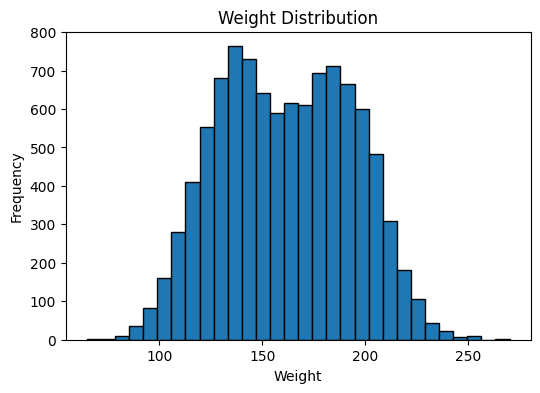

In [8]:
#Plot Histogram for Weight
plt.figure(figsize=(6,4))
plt.hist(df['Weight'], bins=30, edgecolor='black')
plt.title("Weight Distribution")
plt.xlabel("Weight")
plt.ylabel("Frequency")
plt.show()

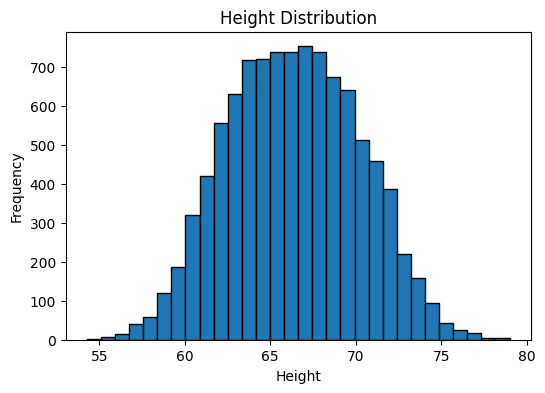

In [9]:
#plot Histogram for Height
plt.figure(figsize=(6,4))
plt.hist(df['Height'], bins=30, edgecolor='black')
plt.title("Height Distribution")
plt.xlabel("Height")
plt.ylabel("Frequency")
plt.show()

In [10]:
# Detect Weight Outliers using IQR
Q1_weight = df['Weight'].quantile(0.25)
Q3_weight = df['Weight'].quantile(0.75)
IQR_weight = Q3_weight - Q1_weight

lower_weight = Q1_weight - 1.5 * IQR_weight
upper_weight = Q3_weight + 1.5 * IQR_weight

weight_outliers = df[(df['Weight'] < lower_weight) | (df['Weight'] > upper_weight)]

print("\nWeight Outliers:")
print(weight_outliers)


Weight Outliers:
     Gender     Height      Weight
2014   Male  78.998742  269.989699


In [11]:
#Detect Height Outliers using IQR
Q1_height = df['Height'].quantile(0.25)
Q3_height = df['Height'].quantile(0.75)
IQR_height = Q3_height - Q1_height

lower_height = Q1_height - 1.5 * IQR_height
upper_height = Q3_height + 1.5 * IQR_height

height_outliers = df[(df['Height'] < lower_height) | (df['Height'] > upper_height)]

print("\nHeight Outliers:")
print(height_outliers)


Height Outliers:
      Gender     Height      Weight
994     Male  78.095867  255.690835
1317    Male  78.462053  227.342565
2014    Male  78.998742  269.989699
3285    Male  78.528210  253.889004
3757    Male  78.621374  245.733783
6624  Female  54.616858   71.393749
7294  Female  54.873728   78.606670
9285  Female  54.263133   64.700127


In [12]:
#Replace Outliers with Mean
df_mean = df.copy()

weight_mean = df_mean['Weight'].mean()
height_mean = df_mean['Height'].mean()

df_mean.loc[(df_mean['Weight'] < lower_weight) | (df_mean['Weight'] > upper_weight), 'Weight'] = weight_mean

df_mean.loc[(df_mean['Height'] < lower_height) | (df_mean['Height'] > upper_height), 'Height'] = height_mean

print("\nDataset after replacing outliers with Mean:")
print(df_mean)


Dataset after replacing outliers with Mean:
      Gender     Height      Weight
0       Male  73.847017  241.893563
1       Male  68.781904  162.310473
2       Male  74.110105  212.740856
3       Male  71.730978  220.042470
4       Male  69.881796  206.349801
...      ...        ...         ...
9995  Female  66.172652  136.777454
9996  Female  67.067155  170.867906
9997  Female  63.867992  128.475319
9998  Female  69.034243  163.852461
9999  Female  61.944246  113.649103

[10000 rows x 3 columns]


In [13]:
#Replace Outliers with Median
df_median = df.copy()

weight_median = df_median['Weight'].median()
height_median = df_median['Height'].median()

df_median.loc[(df_median['Weight'] < lower_weight) | (df_median['Weight'] > upper_weight), 'Weight'] = weight_median

df_median.loc[(df_median['Height'] < lower_height) | (df_median['Height'] > upper_height), 'Height'] = height_median

print("\nDataset after replacing outliers with Median:")
print(df_median)


Dataset after replacing outliers with Median:
      Gender     Height      Weight
0       Male  73.847017  241.893563
1       Male  68.781904  162.310473
2       Male  74.110105  212.740856
3       Male  71.730978  220.042470
4       Male  69.881796  206.349801
...      ...        ...         ...
9995  Female  66.172652  136.777454
9996  Female  67.067155  170.867906
9997  Female  63.867992  128.475319
9998  Female  69.034243  163.852461
9999  Female  61.944246  113.649103

[10000 rows x 3 columns]
